<a href="https://colab.research.google.com/github/hadi-hosseini/bandit/blob/main/Bandit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import cvxpy as cp
import numpy as np
from scipy.stats import ortho_group
from tqdm import tqdm
import random
import matplotlib.pyplot as plt

# Parameters
k = 3
d = 1000
n_samples = 3000
sigma = 1.0
T = 100

orthogonal_matrix = ortho_group.rvs(dim=d)
mu = orthogonal_matrix[:k]
print(mu)

[[-0.04248918  0.00132024  0.07569514 ... -0.02099049 -0.05562109
   0.03081338]
 [-0.01075561  0.0210358  -0.01875328 ... -0.0193197  -0.02518051
   0.00790128]
 [-0.02206831  0.01271262  0.01448277 ...  0.00794914 -0.01450032
  -0.00720431]]


In [ ]:
# Verify orthogonality
for i in range(k):
    for j in range(i+1, k):
        print(f"Dot product μ_{i+1}·μ_{j+1}: {np.dot(mu[i], mu[j])}")

Dot product μ_1·μ_2: -4.0766001685454967e-17
Dot product μ_1·μ_3: -7.266865061084093e-17
Dot product μ_2·μ_3: 1.1939776424496618e-17


In [ ]:
# create offline dataset
def create_logged_data(k, d, n_samples, sigma, mu):
  samples = []
  for i in range(k):
    # Generate samples from N(μ_i, σ²I)
    samples.append(np.random.normal(loc=mu[i], scale=sigma, size=(n_samples, d)))
  return samples

logged_data = create_logged_data(k, d, n_samples, sigma, mu)

In [ ]:
# implement UCB algorithm
class UCBAlgorithm:
    def __init__(self, k, d, true_means, logged_data, perturbation):
        self.k = k
        self.d = d
        self.true_means = true_means
        self.logged_data = logged_data

        self.N = np.zeros(k)
        self.total_rewards = np.zeros(k)
        self.empirical_rewards = np.zeros(k)
        self.empirical_means = np.zeros((k, d))
        self.perturbation = perturbation

    def get_reward(self, x):
        return np.dot(self.true_means[0] + self.perturbation, x)

    def select_arm(self, t):
        if t < self.k:
            return t

        ucb_values = np.zeros(self.k)
        for j in range(self.k):
            mean_term = self.empirical_rewards[j]
            confidence_bound = math.sqrt((2 * math.log(t)) / self.N[j])

            ucb_values[j] = mean_term + confidence_bound

        return np.argmax(ucb_values)

    def update(self, arm, reward):
        self.N[arm] += 1
        self.total_rewards[arm] += reward
        self.empirical_rewards[arm] = self.total_rewards[arm] / self.N[arm]

    def run(self, T):
        rewards = np.zeros(T)
        chosen_arms = np.zeros(T, dtype=int)

        for t in tqdm(range(T)):
            arm = self.select_arm(t)
            sample = self.logged_data[arm][int(self.N[arm])]
            reward = self.get_reward(sample)

            self.update(arm, reward)
            self.empirical_means[arm] = self.empirical_means[arm] + (sample - self.empirical_means[arm])/self.N[arm]

            rewards[t] = reward
            chosen_arms[t] = arm

        return rewards, chosen_arms

In [ ]:
# run UCB without perturbation
perturbation = 0.0
ucb = UCBAlgorithm(k, d, mu, logged_data, perturbation)
rewards, chosen_arms = ucb.run(T)
print("\nNumber of pulls per arm:", ucb.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 28763.57it/s]


Number of pulls per arm: [95.  3.  2.]
[0 1 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
def random_perturbation(d, epsilon):
    perturbation = np.random.randn(d)
    perturbation = epsilon * perturbation / np.linalg.norm(perturbation)
    return perturbation

epsilon = 0.5
random_perturbation = random_perturbation(d, epsilon)
ucb = UCBAlgorithm(k, d, mu, logged_data, random_perturbation)
rewards, chosen_arms = ucb.run(T)
print("\nNumber of pulls per arm:", ucb.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 18472.23it/s]


Number of pulls per arm: [94.  3.  3.]
[0 1 2 0 0 0 0 1 0 0 0 0 0 2 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
# find adversary perturbation
# should learn this perturbation based on the logged data

class FindPerturbation:
    def __init__(self, k, d, true_means, logged_data, epsilon, qp=False, M=1, targeted=False, target_arm=1, infinity_attack=False):
        self.k = k
        self.d = d
        self.true_means = true_means
        self.logged_data = logged_data
        self.epsilon = epsilon
        self.qp = qp
        self.M = M # alternatives
        self.targeted = targeted
        self.infinity_attack = infinity_attack

        self.N = np.zeros(k)
        self.empirical_means = np.zeros((k, d))
        self.perturbation = None
        self.history = []
        self.all_perturbs = []
        self.target_arm = target_arm
        self.turn = 1

    def select_arm(self, t):
        if t < self.k:
            return t

        ### targetted
        if self.targeted:
          return self.target_arm

        ### untargetted
        else:
          self.turn += 1
          if self.turn == k:
            self.turn = 1
          return self.turn

    def find_perturbation_optimal_only(self, arm, t):
        x = cp.Variable(self.d)

        d_0 = self.empirical_means[arm] - self.empirical_means[0]
        c_0 = (math.sqrt(2 * math.log(t) / self.N[0]) - math.sqrt(2 * math.log(t) / self.N[arm])) - np.dot(self.true_means[0], d_0)
        self.history.append((d_0, c_0))


        constraints = []
        for (d_0, c_0) in self.history:
            constraints.append(x @ d_0 >= c_0 + 1e-6)
        constraints.append(cp.norm(x, 2) <= self.epsilon)
        prob = cp.Problem(cp.Minimize(0), constraints)
        prob.solve()

        if prob.status == 'optimal':
          self.all_perturbs.append(x.value)
          return x.value
        else:
          return None

    def find_perturbation(self, arm, t):
        x = cp.Variable(self.d)

        for j in range(self.k):
            if j != arm:
              d_j = self.empirical_means[arm] - self.empirical_means[j]
              c_j = (math.sqrt((2 * math.log(t)) / self.N[j]) - math.sqrt((2 * math.log(t)) / self.N[arm])) - np.dot(self.true_means[0], d_j)
              self.history.append((d_j, c_j))

        constraints = []
        for (d_j, c_j) in self.history:
            constraints.append(x @ d_j >= c_j + 1e-6)
        if qp:
          if self.infinity_attack:
            objective = cp.Minimize(cp.norm(x, "inf"))
          else:
            objective = cp.Minimize(cp.norm(x, 2))
          prob = cp.Problem(objective, constraints)
        else:
          if self.infinity_attack:
            constraints.append(cp.norm(x, "inf") <= self.epsilon)
          else:
            constraints.append(cp.norm(x, 2) <= self.epsilon)
          prob = cp.Problem(cp.Minimize(0), constraints)
        prob.solve()

        if prob.status == 'optimal':
          self.all_perturbs.append(x.value)
          return x.value
        else:
          return None


    def run(self, T, mode=1):
        chosen_arms = np.zeros(T, dtype=int)

        for t in tqdm(range(T)):
            arm = self.select_arm(t)

            if t >= self.k and ((t-k) % self.M == 0):
              if mode == 1: # check all inequalities
                perturbation = self.find_perturbation(arm, t)
              elif mode == 2: # check just optimal inequalities
                perturbation = self.find_perturbation_optimal_only(arm, t)


              if perturbation is None:
                return chosen_arms

              self.perturbation = perturbation

            sample = self.logged_data[arm][int(self.N[arm])]
            self.N[arm] += 1
            self.empirical_means[arm] = self.empirical_means[arm] + (sample - self.empirical_means[arm])/self.N[arm]

            chosen_arms[t] = arm

        return chosen_arms

## ABLATION 1 (CHECK ALL INEQUALITIES)

In [ ]:
# check all inequalities (mode=1)
epsilon = 0.5
qp = False
find_perturbation = FindPerturbation(k, d, mu, logged_data, epsilon, qp)
chosen_arms = find_perturbation.run(T, mode=1)
print("\nNumber of pulls per arm:", find_perturbation.N)
print(chosen_arms)

100%|██████████| 100/100 [01:04<00:00,  1.56it/s]


Number of pulls per arm: [ 1. 49. 50.]
[0 1 2 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]


In [ ]:
perturbation = find_perturbation.perturbation
norm_two = np.linalg.norm(perturbation)
norm_infinity = np.linalg.norm(perturbation, ord=np.inf)
print("norm 2:", norm_two)
print("norm infinity: ", norm_infinity)

norm 2: 0.46259661535943447
norm infinity:  0.04856832419327202


In [ ]:
# all_perturbs = find_perturbation.all_perturbs

# for hist in all_perturbs:
#   ucb_with_perturb = UCBAlgorithm(k, d, mu, logged_data, hist)
#   rewards, chosen_arms = ucb_with_perturb.run(T)
#   print("\nNumber of pulls per arm:", ucb_with_perturb.N)
#   print(chosen_arms)

In [ ]:
# run UCB with perturbation
ucb_with_perturb = UCBAlgorithm(k, d, mu, logged_data, perturbation)
rewards, chosen_arms = ucb_with_perturb.run(T)
print("\nNumber of pulls per arm:", ucb_with_perturb.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 31583.61it/s]


Number of pulls per arm: [ 1. 49. 50.]
[0 1 2 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]


In [ ]:
print(len(find_perturbation.history))

194


## ABLATION 2 (CHECK ONLY OPTIMAL INEQUALITIES)

In [ ]:
# check just optimal inequalities (mode=2)
epsilon = 0.5
qp = False
find_perturbation = FindPerturbation(k, d, mu, logged_data, epsilon, qp)
chosen_arms = find_perturbation.run(T, mode=2)
print("\nNumber of pulls per arm:", find_perturbation.N)
print(chosen_arms)

100%|██████████| 100/100 [00:19<00:00,  5.12it/s]


Number of pulls per arm: [ 1. 49. 50.]
[0 1 2 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]


In [ ]:
perturbation = find_perturbation.perturbation
norm_two = np.linalg.norm(perturbation)
norm_infinity = np.linalg.norm(perturbation, ord=np.inf)
print("norm 2:", norm_two)
print("norm infinity: ", norm_infinity)

norm 2: 0.25328376898327676
norm infinity:  0.026765236187500797


In [ ]:
# run UCB with perturbation
ucb_with_perturb = UCBAlgorithm(k, d, mu, logged_data, perturbation)
rewards, chosen_arms = ucb_with_perturb.run(T)
print("\nNumber of pulls per arm:", ucb_with_perturb.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 25722.46it/s]


Number of pulls per arm: [ 1.  3. 96.]
[0 1 2 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
print(len(find_perturbation.history))

97


## ABLATION 3 (QP)

In [ ]:
# check all inequalities (mode=1)
epsilon = 0.5
qp = True
find_perturbation = FindPerturbation(k, d, mu, logged_data, epsilon, qp)
chosen_arms = find_perturbation.run(T, mode=1)
print("\nNumber of pulls per arm:", find_perturbation.N)
print(chosen_arms)

100%|██████████| 100/100 [01:20<00:00,  1.25it/s]


Number of pulls per arm: [ 1. 49. 50.]
[0 1 2 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]


In [ ]:
perturbation = find_perturbation.perturbation
norm_two = np.linalg.norm(perturbation)
norm_infinity = np.linalg.norm(perturbation, ord=np.inf)
print("norm 2:", norm_two)
print("norm infinity: ", norm_infinity)

norm 2: 0.23645595880689904
norm infinity:  0.023582754466023557


In [ ]:
# run UCB with perturbation
ucb_with_perturb = UCBAlgorithm(k, d, mu, logged_data, perturbation)
rewards, chosen_arms = ucb_with_perturb.run(T)
print("\nNumber of pulls per arm:", ucb_with_perturb.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 25289.74it/s]


Number of pulls per arm: [ 1. 49. 50.]
[0 1 2 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]


In [ ]:
print(len(find_perturbation.history))

194


## ABLATION 4 (M alternatives)

In [ ]:
# check all inequalities (mode=1)
epsilon = 0.5
qp = False
alternatives = True
M = 10 # alternatives
find_perturbation = FindPerturbation(k, d, mu, logged_data, epsilon, qp, M)
chosen_arms = find_perturbation.run(T, mode=1)
print("\nNumber of pulls per arm:", find_perturbation.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 279.23it/s]


Number of pulls per arm: [ 1. 49. 50.]
[0 1 2 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]


In [ ]:
perturbation = find_perturbation.perturbation
norm_two = np.linalg.norm(perturbation)
norm_infinity = np.linalg.norm(perturbation, ord=np.inf)
print("norm 2:", norm_two)
print("norm infinity: ", norm_infinity)

norm 2: 0.22515549519604225
norm infinity:  0.025460802737969166


In [ ]:
# run UCB with perturbation
ucb_with_perturb = UCBAlgorithm(k, d, mu, logged_data, perturbation)
rewards, chosen_arms = ucb_with_perturb.run(T)
print("\nNumber of pulls per arm:", ucb_with_perturb.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 37715.17it/s]


Number of pulls per arm: [ 1.  1. 98.]
[0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
print(len(find_perturbation.history))

20


## Ablation 5 (Targeted Attack)

In [ ]:
# check all inequalities (mode=1)
epsilon = 0.5
qp = False
find_perturbation = FindPerturbation(k, d, mu, logged_data, epsilon, qp, targeted=True, target_arm=2)
chosen_arms = find_perturbation.run(T, mode=1)
print("\nNumber of pulls per arm:", find_perturbation.N)
print(chosen_arms)

100%|██████████| 100/100 [00:48<00:00,  2.07it/s]


Number of pulls per arm: [ 1.  1. 98.]
[0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
perturbation = find_perturbation.perturbation
norm_two = np.linalg.norm(perturbation)
norm_infinity = np.linalg.norm(perturbation, ord=np.inf)
print("norm 2:", norm_two)
print("norm infinity: ", norm_infinity)

norm 2: 0.25039292637831795
norm infinity:  0.02416315905500752


In [ ]:
# run UCB with perturbation
ucb_with_perturb = UCBAlgorithm(k, d, mu, logged_data, perturbation)
rewards, chosen_arms = ucb_with_perturb.run(T)
print("\nNumber of pulls per arm:", ucb_with_perturb.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 32521.55it/s]


Number of pulls per arm: [ 1.  1. 98.]
[0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
print(len(find_perturbation.history))

194


## ABLATION 6 (infinity norm)

In [ ]:
epsilon = 1/125
qp = False
find_perturbation = FindPerturbation(k, d, mu, logged_data, epsilon, qp, targeted=True, target_arm=2, infinity_attack=True)
chosen_arms = find_perturbation.run(T, mode=1)
print("\nNumber of pulls per arm:", find_perturbation.N)
print(chosen_arms)

100%|██████████| 100/100 [01:10<00:00,  1.41it/s]


Number of pulls per arm: [ 1.  1. 98.]
[0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
perturbation = find_perturbation.perturbation
norm_two = np.linalg.norm(perturbation)
norm_infinity = np.linalg.norm(perturbation, ord=np.inf)
print("norm 2:", norm_two)
print("norm infinity: ", norm_infinity)

norm 2: 0.19407099736864372
norm infinity:  0.007492995521545993


In [ ]:
# run UCB with perturbation
ucb_with_perturb = UCBAlgorithm(k, d, mu, logged_data, perturbation)
rewards, chosen_arms = ucb_with_perturb.run(T)
print("\nNumber of pulls per arm:", ucb_with_perturb.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 28362.89it/s]


Number of pulls per arm: [ 1.  1. 98.]
[0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
print(len(find_perturbation.history))

194


## ABLATION 7 (Restricted Threat Model: Infer Mus)

In [ ]:
empirical_mus = [np.mean(arm_samples, axis=0) for arm_samples in logged_data]
error = np.linalg.norm(empirical_mus[0] - mu[0])
print("L2 distance:", error)

L2 distance: 0.5886134107411902


In [ ]:
# check all inequalities (mode=1)
epsilon = 0.5
qp = False
find_perturbation = FindPerturbation(k, d, empirical_mus, logged_data, epsilon, qp, targeted=True, target_arm=2)
chosen_arms = find_perturbation.run(T, mode=1)
print("\nNumber of pulls per arm:", find_perturbation.N)
print(chosen_arms)

100%|██████████| 100/100 [00:48<00:00,  2.07it/s]


Number of pulls per arm: [ 1.  1. 98.]
[0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
perturbation = find_perturbation.perturbation
norm_two = np.linalg.norm(perturbation)
norm_infinity = np.linalg.norm(perturbation, ord=np.inf)
print("norm 2:", norm_two)
print("norm infinity: ", norm_infinity)

norm 2: 0.2483752815426301
norm infinity:  0.02356725097424637


In [ ]:
# run UCB with perturbation
ucb_with_perturb = UCBAlgorithm(k, d, mu, logged_data, perturbation)
rewards, chosen_arms = ucb_with_perturb.run(T)
print("\nNumber of pulls per arm:", ucb_with_perturb.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 20417.19it/s]


Number of pulls per arm: [ 1.  1. 98.]
[0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
print(len(find_perturbation.history))

194


## ABLATION 8 (Which part is better for attack (first or last)?)

In [ ]:
# find adversary perturbation
# should learn this perturbation based on the logged data

class FindPerturbationWithinInterval:
    def __init__(self, k, d, true_means, logged_data, epsilon, interval, qp=False, M=1, targeted=False, target_arm=1, infinity_attack=False):
        self.k = k
        self.d = d
        self.true_means = true_means
        self.logged_data = logged_data
        self.epsilon = epsilon
        self.qp = qp
        self.M = M # alternatives
        self.targeted = targeted
        self.infinity_attack = infinity_attack
        self.interval = interval

        self.N = np.zeros(k)
        self.empirical_means = np.zeros((k, d))
        self.perturbation = 0.0
        self.history = []
        self.all_perturbs = []
        self.target_arm = target_arm
        self.turn = 1

    def select_arm(self, t):
        if t < self.k:
            return t

        if t in self.interval:
          ### targetted
          if self.targeted:
            return self.target_arm

          ### untargetted
          else:
            self.turn += 1
            if self.turn == k:
              self.turn = 1
            return self.turn

    def find_perturbation_optimal_only(self, arm, t):
        x = cp.Variable(self.d)

        d_0 = self.empirical_means[arm] - self.empirical_means[0]
        c_0 = (math.sqrt(2 * math.log(t) / self.N[0]) - math.sqrt(2 * math.log(t) / self.N[arm])) - np.dot(self.true_means[0], d_0)
        self.history.append((d_0, c_0))


        constraints = []
        for (d_0, c_0) in self.history:
            constraints.append(x @ d_0 >= c_0 + 1e-6)
        constraints.append(cp.norm(x, 2) <= self.epsilon)
        prob = cp.Problem(cp.Minimize(0), constraints)
        prob.solve()

        if prob.status == 'optimal':
          self.all_perturbs.append(x.value)
          return x.value
        else:
          return None

    def find_perturbation(self, arm, t):
        x = cp.Variable(self.d)

        for j in range(self.k):
            if j != arm:
              d_j = self.empirical_means[arm] - self.empirical_means[j]
              c_j = (math.sqrt((2 * math.log(t)) / self.N[j]) - math.sqrt((2 * math.log(t)) / self.N[arm])) - np.dot(self.true_means[0], d_j)
              self.history.append((d_j, c_j))

        constraints = []
        for (d_j, c_j) in self.history:
            constraints.append(x @ d_j >= c_j + 1e-6)
        if qp:
          if self.infinity_attack:
            objective = cp.Minimize(cp.norm(x, "inf"))
          else:
            objective = cp.Minimize(cp.norm(x, 2))
          prob = cp.Problem(objective, constraints)
        else:
          if self.infinity_attack:
            constraints.append(cp.norm(x, "inf") <= self.epsilon)
          else:
            constraints.append(cp.norm(x, 2) <= self.epsilon)
          prob = cp.Problem(cp.Minimize(0), constraints)
        prob.solve()

        if prob.status == 'optimal':
          self.all_perturbs.append(x.value)
          return x.value
        else:
          return None

    def run(self, T, mode=1):
        chosen_arms = np.zeros(T, dtype=int)

        for t in tqdm(range(T)):
            arm = self.select_arm(t)

            if t >= self.k and not t in self.interval:
              return chosen_arms

            if t >= self.k and ((t-k) % self.M == 0):
              if mode == 1: # check all inequalities
                perturbation = self.find_perturbation(arm, t)
              elif mode == 2: # check just optimal inequalities
                perturbation = self.find_perturbation_optimal_only(arm, t)


              if perturbation is None:
                return chosen_arms

              self.perturbation = perturbation

            sample = self.logged_data[arm][int(self.N[arm])]
            self.N[arm] += 1
            self.empirical_means[arm] = self.empirical_means[arm] + (sample - self.empirical_means[arm])/self.N[arm]

            chosen_arms[t] = arm

        return chosen_arms

100%|██████████| 100/100 [00:00<00:00, 17557.47it/s]



Number of pulls per arm: [95.  3.  2.]
[0 1 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
----------------------------------------


100%|██████████| 100/100 [00:00<00:00, 28793.19it/s]



Number of pulls per arm: [82.  8. 10.]
[0 1 2 2 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 1 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 2 2 2 2 2 0 0 0 0 0 0 2 2 0 0 0 1 1 1 0 0 0 0 0 0 0]
----------------------------------------


100%|██████████| 100/100 [00:00<00:00, 32620.19it/s]


...


Number of pulls per arm: [ 1.  1. 98.]
[0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
----------------------------------------


100%|██████████| 100/100 [00:00<00:00, 24324.68it/s]



Number of pulls per arm: [ 1.  1. 98.]
[0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
----------------------------------------


100%|██████████| 100/100 [00:00<00:00, 31446.27it/s]



Number of pulls per arm: [ 1.  1. 98.]
[0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
----------------------------------------


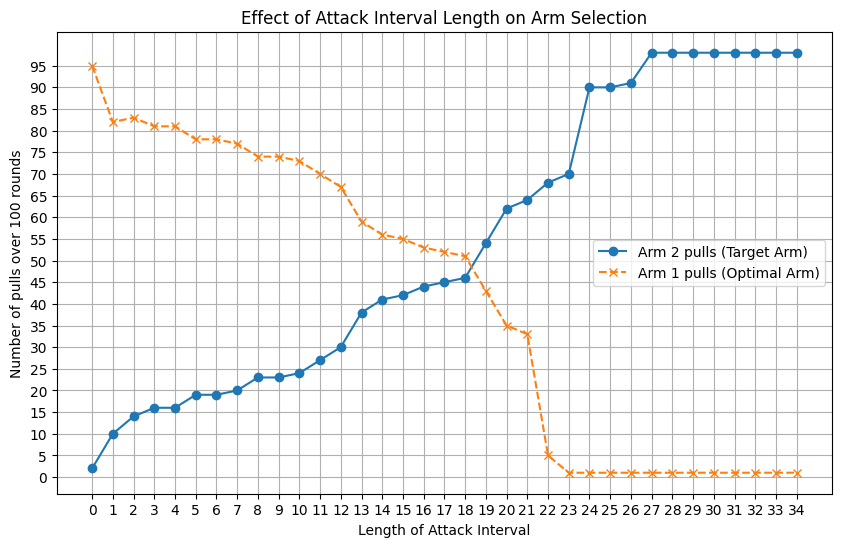

In [ ]:
arm1_pulls = []
arm2_pulls = []
epsilon = 0.5
qp = False
attack_length = 35
for length in range(0, attack_length):
    interval = list(range(k, k + length))
    find_perturbation_within_interval = FindPerturbationWithinInterval(k, d, mu, logged_data, epsilon, interval, qp, targeted=True, target_arm=2)
    chosen_arms_attack_phase = find_perturbation_within_interval.run(T, mode=1)
    perturbation = find_perturbation_within_interval.perturbation
    ucb_with_perturb = UCBAlgorithm(k, d, mu, logged_data, perturbation)
    rewards, chosen_arms_full_run = ucb_with_perturb.run(T)
    arm2_pulls.append(np.sum(chosen_arms_full_run == 2))
    arm1_pulls.append(np.sum(chosen_arms_full_run == 0))

    print("\nNumber of pulls per arm:", ucb_with_perturb.N)
    print(chosen_arms_full_run)
    print(40 * '-')


lengths = list(range(0, attack_length))
plt.figure(figsize=(10, 6))
plt.plot(lengths, arm2_pulls, marker='o', linestyle='-', label='Arm 2 pulls (Target Arm)')
plt.plot(lengths, arm1_pulls, marker='x', linestyle='--', label='Arm 1 pulls (Optimal Arm)')

plt.xlabel('Length of Attack Interval')
plt.xticks(lengths)
plt.yticks(list(range(0, T, 5)))
plt.ylabel(f'Number of pulls over {T} rounds')
plt.title('Effect of Attack Interval Length on Arm Selection')
plt.legend()
plt.grid(True)
plt.show()


## ETC Attack

In [ ]:
# implement UCB algorithm
class ETCAlgorithm:
    def __init__(self, k, m, d, true_means, logged_data, perturbation):
        self.k = k
        self.m = m
        self.d = d
        self.true_means = true_means
        self.logged_data = logged_data

        self.N = np.zeros(k)
        self.total_rewards = np.zeros(k)
        self.empirical_rewards = np.zeros(k)
        self.empirical_means = np.zeros((k, d))
        self.perturbation = perturbation

    def get_reward(self, x):
        return np.dot(self.true_means[0] + self.perturbation, x)

    def select_arm(self, t):
        if t < self.k * self.m:
            return t % k

        return np.argmax(self.empirical_rewards)

    def update(self, arm, reward):
        self.total_rewards[arm] += reward
        self.empirical_rewards[arm] = self.total_rewards[arm] / self.N[arm]

    def run(self, T):
        rewards = np.zeros(T)
        chosen_arms = np.zeros(T, dtype=int)

        for t in tqdm(range(T)):
            arm = self.select_arm(t)
            sample = self.logged_data[arm][int(self.N[arm])]
            reward = self.get_reward(sample)
            self.N[arm] += 1

            if t < self.k * self.m:
              self.update(arm, reward)
              self.empirical_means[arm] = self.empirical_means[arm] + (sample - self.empirical_means[arm])/self.N[arm]

            rewards[t] = reward
            chosen_arms[t] = arm

        return rewards, chosen_arms

In [ ]:
# run ETC without perturbation
perturbation = 0.0
m = 5
etc = ETCAlgorithm(k, m, d, mu, logged_data, perturbation)
rewards, chosen_arms = etc.run(T)
print("\nNumber of pulls per arm:", etc.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 56542.25it/s]


Number of pulls per arm: [90.  5.  5.]
[0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
# find adversary perturbation
# should learn this perturbation based on the logged data

class FindPerturbationETC:
    def __init__(self, k, m, d, target_arm, true_means, logged_data, epsilon, qp=False):
        self.k = k
        self.m = m
        self.d = d
        self.true_means = true_means
        self.logged_data = logged_data
        self.epsilon = epsilon
        self.qp = qp
        self.target_arm = target_arm

        self.N = np.zeros(k)
        self.empirical_means = np.zeros((k, d))
        self.perturbation = None

    def select_arm(self, t):
        if t < self.k * self.m:
            return t % k

        return self.target_arm

    def find_perturbation_with_l2_ball(self, arm, t):
        x = cp.Variable(self.d)
        constraints = []

        for j in range(self.k):
            if j != arm:
              d_j = self.empirical_means[arm] - self.empirical_means[j]
              c_j = - np.dot(self.true_means[0], d_j)
              constraints.append(x @ d_j >= c_j + 1e-6)

        if qp:
          objective = cp.Minimize(cp.norm(x, 2))
          prob = cp.Problem(objective, constraints)
        else:
          constraints.append(cp.norm(x, 2) <= self.epsilon)
          prob = cp.Problem(cp.Minimize(0), constraints)
        prob.solve()

        if prob.status == 'optimal':
          return x.value
        else:
          return None


    def run(self, T):
        chosen_arms = np.zeros(T, dtype=int)

        for t in tqdm(range(T)):
            arm = self.select_arm(t)

            if t == self.m * self.k:
              self.perturbation = self.find_perturbation_with_l2_ball(arm, t)
              return chosen_arms

            sample = self.logged_data[arm][int(self.N[arm])]
            self.N[arm] += 1
            self.empirical_means[arm] = self.empirical_means[arm] + (sample - self.empirical_means[arm])/self.N[arm]

            chosen_arms[t] = arm

        return chosen_arms

In [ ]:
# check all inequalities (mode=1)
epsilon = 0.5
qp = False
target_arm = 2
m = 5
find_perturbation = FindPerturbationETC(k, m, d, target_arm, mu, logged_data, epsilon, qp)
chosen_arms = find_perturbation.run(T)
print("\nNumber of pulls per arm:", find_perturbation.N)
print(chosen_arms)

 15%|█▌        | 15/100 [00:00<00:00, 517.36it/s]


Number of pulls per arm: [5. 5. 5.]
[0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
perturbation = find_perturbation.perturbation
norm = np.linalg.norm(perturbation)
print(norm)

0.07428831635278174


In [ ]:
# run ETC with perturbation
m = 5
etc = ETCAlgorithm(k, m, d, mu, logged_data, perturbation)
rewards, chosen_arms = etc.run(T)
print("\nNumber of pulls per arm:", etc.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 44606.02it/s]


Number of pulls per arm: [ 5.  5. 90.]
[0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


## epsilon-greedy Attack

In [ ]:
# implement epsilon_greedy algorithm
class EpsilonGreedyAlgorithm:
    def __init__(self, k, d, epsilon, true_means, logged_data, perturbation):
        self.k = k
        self.d = d
        self.true_means = true_means
        self.logged_data = logged_data
        self.epsilon = epsilon

        self.N = np.zeros(k)
        self.total_rewards = np.zeros(k)
        self.empirical_rewards = np.zeros(k)
        self.perturbation = perturbation

    def get_reward(self, x):
        return np.dot(self.true_means[0] + self.perturbation, x)

    def select_arm(self, t):
        if t < self.k:
            return t

        else:
          if random.random() < self.epsilon:
            return random.randint(0, k - 1)
          else:
            return np.argmax(self.empirical_rewards)

    def update(self, arm, reward):
        self.N[arm] += 1
        self.total_rewards[arm] += reward
        self.empirical_rewards[arm] = self.total_rewards[arm] / self.N[arm]

    def run(self, T):
        rewards = np.zeros(T)
        chosen_arms = np.zeros(T, dtype=int)

        for t in tqdm(range(T)):
            arm = self.select_arm(t)
            sample = self.logged_data[arm][int(self.N[arm])]
            reward = self.get_reward(sample)
            self.update(arm, reward)

            rewards[t] = reward
            chosen_arms[t] = arm

        return rewards, chosen_arms

In [ ]:
# run epsilon_greedy without perturbation
perturbation = 0.0
epsilon = 0.1
random.seed(42)
epsilon_greedy = EpsilonGreedyAlgorithm(k, d, epsilon, mu, logged_data, perturbation)
rewards, chosen_arms = epsilon_greedy.run(T)
print("\nNumber of pulls per arm:", epsilon_greedy.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 51896.86it/s]


Number of pulls per arm: [93.  4.  3.]
[0 1 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 1 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
# find adversary perturbation
# should learn this perturbation based on the logged data

class FindPerturbationEpsilonGreedyAlgorithm:
    def __init__(self, k, d, epsilon, target_arm, true_means, logged_data, epsilon_attack, qp=False):
        self.k = k
        self.d = d
        self.true_means = true_means
        self.logged_data = logged_data
        self.epsilon_attack = epsilon_attack
        self.qp = qp
        self.target_arm = target_arm
        self.epsilon = epsilon

        self.N = np.zeros(k)
        self.empirical_means = np.zeros((k, d))
        self.perturbation = None
        self.is_uniform = False
        self.history = []

    def select_arm(self, t):
        if t < self.k:
            return t

        else:
          if random.random() < self.epsilon:
            self.is_uniform = True
            return random.randint(0, k - 1)
          else:
            self.is_uniform = False
            return self.target_arm

    def find_perturbation_with_l2_ball(self, arm, t):
        x = cp.Variable(self.d)
        constraints = []

        for j in range(self.k):
            if j != arm:
              d_j = self.empirical_means[arm] - self.empirical_means[j]
              c_j = - np.dot(self.true_means[0], d_j)
              self.history.append((d_j, c_j))


        for (d_j, c_j) in self.history:
            constraints.append(x @ d_j >= c_j + 1e-6)

        if qp:
          objective = cp.Minimize(cp.norm(x, 2))
          prob = cp.Problem(objective, constraints)
        else:
          constraints.append(cp.norm(x, 2) <= self.epsilon_attack)
          prob = cp.Problem(cp.Minimize(0), constraints)
        prob.solve()

        if prob.status == 'optimal':
          return x.value
        else:
          return None


    def run(self, T):
        chosen_arms = np.zeros(T, dtype=int)

        for t in tqdm(range(T)):
            arm = self.select_arm(t)

            if t >= self.k and not self.is_uniform:
              self.perturbation = self.find_perturbation_with_l2_ball(arm, t)

            sample = self.logged_data[arm][int(self.N[arm])]
            self.N[arm] += 1
            self.empirical_means[arm] = self.empirical_means[arm] + (sample - self.empirical_means[arm])/self.N[arm]

            chosen_arms[t] = arm

        return chosen_arms

In [ ]:
# check all inequalities (mode=1)
epsilon_attack = 0.5
qp = False
target_arm = 2
epsilon = 0.1
random.seed(42)
find_perturbation = FindPerturbationEpsilonGreedyAlgorithm(k, d, epsilon, target_arm, mu, logged_data, epsilon_attack, qp)
chosen_arms = find_perturbation.run(T)
print("\nNumber of pulls per arm:", find_perturbation.N)
print(chosen_arms)

100%|██████████| 100/100 [00:38<00:00,  2.62it/s]


Number of pulls per arm: [ 5.  4. 91.]
[0 1 2 2 1 2 2 2 2 2 2 0 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2
 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
perturbation = find_perturbation.perturbation
norm = np.linalg.norm(perturbation)
print(norm)

0.16625252932134452


In [ ]:
# run epsilon-greedy with perturbation
epsilon = 0.1
random.seed(42)
epsilon_greedy = EpsilonGreedyAlgorithm(k, d, epsilon, mu, logged_data, perturbation)
rewards, chosen_arms = epsilon_greedy.run(T)
print("\nNumber of pulls per arm:", epsilon_greedy.N)
print(chosen_arms)

100%|██████████| 100/100 [00:00<00:00, 27065.26it/s]


Number of pulls per arm: [ 5.  4. 91.]
[0 1 2 2 1 2 2 2 2 2 2 0 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2
 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2]
